# Versuch 2

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from skimage.color import rgb2gray
from pathlib import Path

## Aufgabe 1

### Zuerst Das Bild einlesen, croppen dessen Graustufen isolieren und deren Mittelwerte und Standardabweichungen berechnen.

13, 15, 18, 21, 27, 36, 78, 98, 117, 118, 119, 120, 121, 122, 123, 124, 125, 254, 255, 256, 257, 258, 259, 389, 390, 391, 392, 393, 521, 522, 523, 524, 525, 526


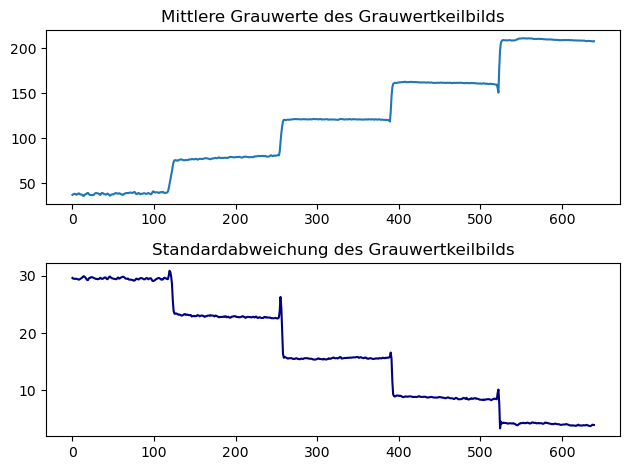


Mittelwerte: ['38.0862', '73.2728', '157.3905', '116.5279', '204.7760']
Standardabweichungen: ['29.5691', '26.7638', '20.6696', '15.8207', '15.1807']


In [2]:

#gw = cv2.imread("./grauwertkeil.png")
img = cv2.imread("./versuch2-1_2.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
g = gray
gray_arr = np.zeros((gray.shape[1]), dtype=float)
gray_arr_mean = np.zeros(5, dtype=float)
gray_arr_std = np.zeros(5, dtype=float)
std_gray = np.zeros((gray.shape[1]), dtype=float)

fig, axs = plt.subplots(2)
gray_val = 0

print(*[i for i in range(gray.shape[1])
        if not (gray_arr.__setitem__(i, np.mean(gray[:, i])) or
                std_gray.__setitem__(i, np.std(gray[:, i])))
                and i > 0 and abs(gray_arr[i-1] - gray_arr[i]) > 1], sep=", ")
#for i in range(0,gray.shape[1]):
#    gray_arr[i] = np.mean(gray[:,i])
#    std_gray[i] = np.std(gray[:,i])
#    if i > 0 and abs(gray_arr[i-1] - gray_arr[i]) > 1:
#        print(i, end=", ")

axs[0].plot(range(0,gray_arr.size), gray_arr)
axs[1].plot(range(0,std_gray.size), std_gray, color='navy')
axs[0].set_title("Mittlere Grauwerte des Grauwertkeilbilds")
axs[1].set_title("Standardabweichung des Grauwertkeilbilds")
plt.tight_layout()
plt.show()
cv2.waitKey(0)
cv2.destroyAllWindows()

gray_arr_mean = [
            np.mean(gray[:,0:99]), np.mean(gray[:,106:235]), np.mean(gray[:,378:505]),
            np.mean(gray[:,242:371]), np.mean(gray[:,512:gray.shape[1]])
          ]

gray_arr_std = [
            np.std(gray[:,0:99]), np.std(gray[:,106:235]), np.std(gray[:,242:371]),
            np.std(gray[:,378:505]), np.std(gray[:,512:gray.shape[1]])
        ]

print("\nMittelwerte:", [f"{i:.4f}" for i in gray_arr_mean])
print("Standardabweichungen:", [f"{i:.4f}" for i in gray_arr_std])

## Aufgabe 2

### Alle Schwarzbilder einlesen und sie in Graubilder übersetzen.

0 544
0 545
0 546


[ WARN:0@14.009] global loadsave.cpp:1063 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


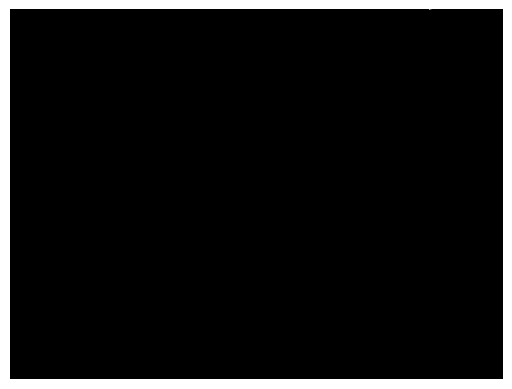

hellster Punkt: 0 544


In [3]:
black_gray_val = []
def contrast(arr): return ((arr - np.min(arr)) / abs(np.max(arr) - np.min(arr))) * 255

list(map(
    lambda i: black_gray_val.append(
        cv2.cvtColor(cv2.imread(f"./schwarz{i}.png"),
                     cv2.COLOR_BGR2GRAY).astype(float)
    ),
    range(10)
))

#for i in range(0, 10):
#    img = cv2.imread(f"./schwarz{i}.png")
#    black_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float)
#    black_gray_val.append(black_gray)

black_gray_val_arr = np.array(black_gray_val)
mean_white = np.full(shape=(black_gray_val_arr.shape[1], black_gray_val_arr.shape[2]), fill_value=100, dtype=float)
for i in range(0, black_gray_val_arr.shape[1]):
    for j in range(0, black_gray_val_arr.shape[2]):
        mean_white[i,j] = np.mean(black_gray_val_arr[:,i,j])
n = contrast(mean_white)
for i in range(0, n.shape[0]):
    for j in range(0, n.shape[1]):
        if mean_white[i,j] > 0: print(i, j)

plt.imshow(contrast(mean_white), cmap='gray',vmax=255,vmin=0)
cv2.imwrite("./mvpblack.png", mean_white)
plt.axis('off')
plt.show()
for i in range(0, n.shape[0]):
    for j in range(0, n.shape[1]):
        if n[i,j] == 255: print("hellster Punkt:", i, j)
mvpb = mean_white

### Liest Dunkelbild ein, subtahiert von einem Eingabebild und gibt das korrigierte Bild aus.

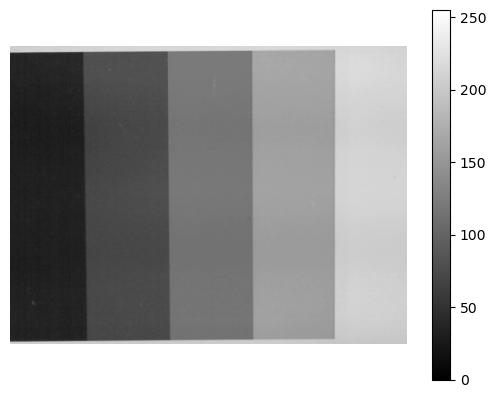

In [4]:
def DarkSubtractPic(picArr):
    black = cv2.cvtColor(cv2.imread(f"./mvpblack.png"), cv2.COLOR_BGR2GRAY)
    out = picArr - black
    cv2.imwrite('./DarkSubtractPic.png', out)
    return out
#plt.imshow(gray, cmap='gray',vmax=255,vmin=0)
plt.imshow(DarkSubtractPic(gray),vmax=255,vmin=0, cmap='gray')

plt.axis('off')
plt.colorbar()
plt.show()

## Aufgabe 3

### 10 Weißbilder einlesen, ihren Mittelwert berechnen, und davon das Dunkelbild berechnen.

170.9
196.8


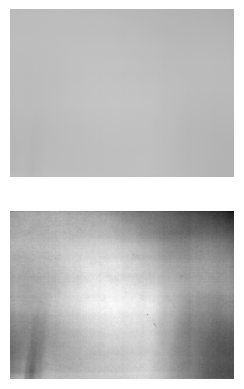

dunkelster Punkt: 0 629


In [5]:
white_gray_val = []

for i in range(0, 10):
    img = cv2.imread(f"./white_{i}.png")
    white_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float64)
    white_gray_val.append(white_gray)

white_gray_val_arr = np.array(white_gray_val)
mean_white = np.full(shape=(white_gray_val_arr.shape[1], white_gray_val_arr.shape[2]), fill_value=100, dtype=np.float64)
for i in range(0, white_gray_val_arr.shape[1]):
    for j in range(0, white_gray_val_arr.shape[2]):
        mean_white[i, j] = np.mean(white_gray_val_arr[:, i, j])
fig, axs = plt.subplots(2)
mean_white = DarkSubtractPic(mean_white)
mean_norm = contrast(mean_white)
cv2.imwrite("./mvpwhite.png", mean_white)
print(np.min(mean_white))
print(np.max(mean_white))
axs[0].imshow(mean_white, cmap='gray',vmax=255,vmin=0, )
axs[1].imshow(mean_norm, cmap='gray')
axs[0].axis('off')
axs[1].axis('off')
plt.show()
cv2.imwrite("./pic.png", mean_norm)
for i in range(0, n.shape[0]):
    for j in range(0, n.shape[1]):
        #if mean_norm[i,j] == 255: print("hellster Punkt:", i, j)
        if mean_norm[i,j] == 0: print("dunkelster Punkt:", i, j)

### Normierung mit Weißbild

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

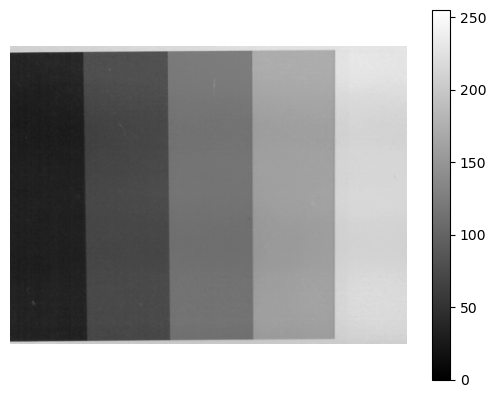

In [6]:
def white_norm(arr):
    normed_white = cv2.cvtColor(cv2.imread("./mvpwhite.png"), cv2.COLOR_BGR2GRAY).astype(np.float64)
    normed_white /= np.mean(normed_white)
    out = DarkSubtractPic(arr) / normed_white
    cv2.imwrite("./wNorm.png", out)
    return out
plt.imshow(white_norm(gray), cmap='gray',vmax=255,vmin=0)
plt.colorbar()
plt.axis('off')

## Aufgabe 4 - Pixelfehler

In [7]:
n = mvpb
for i in range(0, n.shape[0]):
    for j in range(0, n.shape[1]):
        if n[i,j] > 0: print("Hot- oder stuckpixel:", i, j)

Hot- oder stuckpixel: 0 544
Hot- oder stuckpixel: 0 545
Hot- oder stuckpixel: 0 546


## Anwendung Grauwertkeil

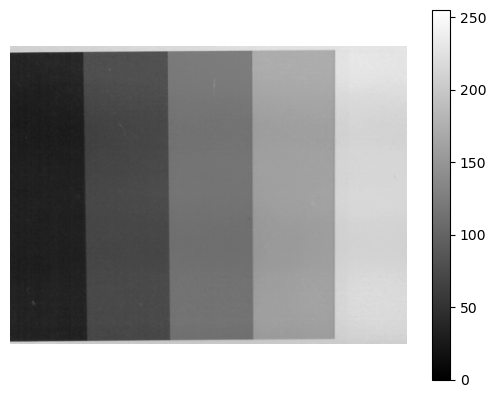

In [8]:
cgwk = white_norm(gray)
cv2.imwrite("./correctedGWK.png", cgwk)
plt.imshow(cgwk, cmap='gray',vmax=255,vmin=0)
plt.axis('off')
plt.colorbar()
plt.show()

## Means und Stds

In [28]:
g_mean_corr = np.zeros(5, dtype=float)
g_std_corr = np.zeros(5, dtype=float)
g_mean_corr[0] = np.mean(cgwk[:,0:99])
g_mean_corr[1] = np.mean(cgwk[:,106:235])
g_mean_corr[2] = np.mean(cgwk[:,242:371])
g_mean_corr[3] = np.mean(cgwk[:,378:505])
g_mean_corr[4] = np.mean(cgwk[:,512:gray.shape[1]])

g_std_corr[0] = np.std(cgwk[:,0:99])
g_std_corr[1] = np.std(cgwk[:,106:235])
g_std_corr[2] = np.std(cgwk[:,242:371])
g_std_corr[3] = np.std(cgwk[:,378:505])
g_std_corr[4] = np.std(cgwk[:,512:gray.shape[1]])

print(g_mean_corr)
print(g_std_corr)


[ 38.34914633  72.44177601 114.33941032 157.69399189 210.49752314]
[29.73576874 26.74522639 21.08229589 17.19757482 16.41796723]


ValueError: x and y must have same first dimension, but have shapes (307200,) and (640,)

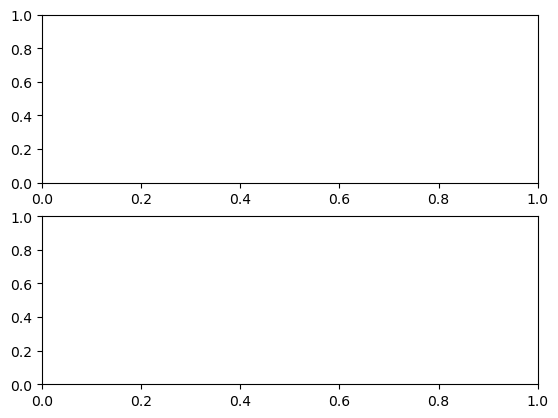

In [31]:
fig, splt = plt.subplots(2)
gw = 0
cgv = np.full((gray.shape[1]), 0, dtype=float)
for i in range(0,gray.shape[1]):
    cgv[i] = np.mean(cgwk[:,i])
    std_gray[i] = np.std(cgwk[:,i])
splt[0].plot(range(0,g.size),cgv)
splt[1].plot(range(0,std_gray.size),std_gray, color='darkslategray')
splt[0].set_title("Mittlere Grauwerte des Grauwertkeilbilds")
splt[1].set_title("Standardabweichung des Grauwertkeilbilds")
plt.tight_layout()
plt.show()